In [244]:
import numpy as np
import pandas as pd
import seaborn as sns
titanic = sns.load_dataset('titanic')
titanic.head()
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [245]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [246]:
titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [247]:
titanic.drop(columns=['who', 'adult_male', 'embark_town', 'alone', 'alive', 'class', 'deck'], inplace=True)

In [248]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [249]:
titanic['embarked'].mode()

,embarked
0,S


In [250]:
titanic['embarked']=titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['age']=titanic['age'].fillna(titanic['age'].median())
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [251]:
titanic.sample(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked
211,1,2,female,35.0,0,0,21.0000,S
848,0,2,male,28.0,0,1,33.0000,S
886,0,2,male,27.0,0,0,13.0000,S
642,0,3,female,2.0,3,2,27.9000,S
459,0,3,male,28.0,0,0,7.7500,Q
865,1,2,female,42.0,0,0,13.0000,S
439,0,2,male,31.0,0,0,10.5000,S
824,0,3,male,2.0,4,1,39.6875,S
578,0,3,female,28.0,1,0,14.4583,C
341,1,1,female,24.0,3,2,263.0000,S


In [252]:
for x in titanic.columns:
    if titanic[x].dtype == 'object':
      titanic[x]=pd.Categorical(titanic[x]).codes

In [253]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    int8   
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    int8   
dtypes: float64(2), int64(4), int8(2)
memory usage: 43.6 KB


In [254]:
np.arange(0, 1.01, 0.05)

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [255]:
titanic.quantile(np.arange(0, 1.01, 0.05))

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0.00,0.0,1.0,0.0,0.42,0.0,0.0,0.00000,0.0
0.05,0.0,1.0,0.0,6.00,0.0,0.0,7.22500,0.0
0.10,0.0,1.0,0.0,16.00,0.0,0.0,7.55000,0.0
0.15,0.0,1.0,0.0,18.00,0.0,0.0,7.75000,0.0
0.20,0.0,1.0,0.0,20.00,0.0,0.0,7.85420,1.0
0.25,0.0,2.0,0.0,22.00,0.0,0.0,7.91040,1.0
0.30,0.0,2.0,0.0,24.00,0.0,0.0,8.05000,2.0
0.35,0.0,2.0,0.0,26.00,0.0,0.0,9.00000,2.0
0.40,0.0,2.0,1.0,28.00,0.0,0.0,10.50000,2.0
0.45,0.0,3.0,1.0,28.00,0.0,0.0,13.00000,2.0


<Axes: >

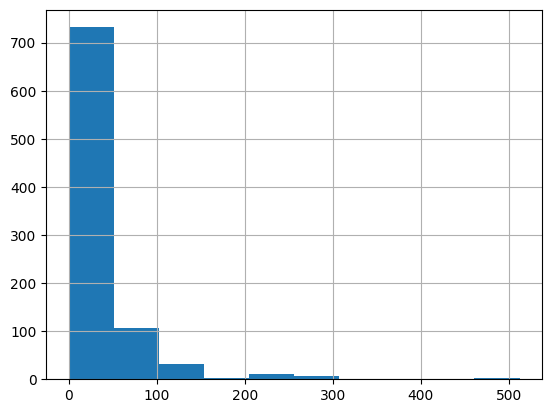

In [256]:
import matplotlib.pyplot as plt
%matplotlib inline
titanic.fare.hist()
plt.show()

In [257]:
print(np.round(titanic.fare.median(), 2))
print(np.round(titanic.fare.mean(), 2))

14.45
32.2


<Axes: >

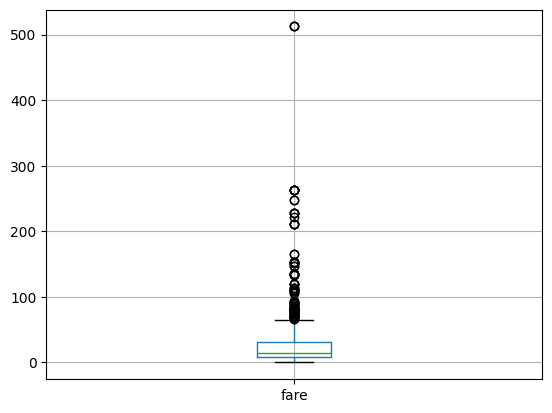

In [258]:
titanic.boxplot(column=['fare'])

In [259]:
titanic.fare.quantile([0, 0.01, 0.02, 0.05, 0.95, 0.99, 1.00])

,fare
0.00,0.00000
0.01,0.00000
0.02,6.39750
0.05,7.22500
0.95,112.07915
0.99,249.00622
1.00,512.32920


In [260]:
titanic.fare = np.clip(titanic.fare, titanic.fare.quantile(0.02), titanic.fare.quantile(0.99))

In [261]:
titanic.fare.describe()
titanic.info()

,fare
count,891.000000
mean,31.336894
std,42.450163
min,6.397500
25%,7.910400
50%,14.454200
75%,31.000000
max,249.006220


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    int8   
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    int8   
dtypes: float64(2), int64(4), int8(2)
memory usage: 43.6 KB


In [262]:
for x in titanic.columns:
    outlier = titanic[x].quantile([0.01, 0.99]).values
    titanic[x] = np.clip(titanic[x], outlier[0], outlier[1])

In [263]:
titanic.describe()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.647587,29.304714,0.499439,0.373737,31.323390,1.536476
std,0.486592,0.836071,0.477990,12.832434,0.966140,0.763306,42.380997,0.791503
min,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,6.397500,0.000000
25%,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,1.000000,28.000000,0.000000,0.000000,14.454200,2.000000
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,1.000000,65.000000,5.000000,4.000000,247.669342,2.000000


# Import Sklearn packages for doing ML modeling

In [264]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression

# STEP 1- CREATE FEATURES AND LABEL

In [265]:
x = titanic.drop(['survived'], axis = 1, inplace=False)
y = titanic['survived']
x.shape
print('\n')
y.shape

(891, 7)

(891,)

In [266]:
from sklearn.preprocessing import MinMaxScaler
scld_titanic = MinMaxScaler(feature_range=(0,1))
titanic_transformed = scld_titanic.fit_transform(x)
scld_titanic_df = pd.DataFrame(titanic_transformed, columns=x.columns)
scld_titanic_df.head()
scld_titanic_df.describe()

,pclass,sex,age,sibsp,parch,fare,embarked
0,1.0,1.0,0.328125,0.2,0.0,0.003533,1.0
1,0.0,0.0,0.578125,0.2,0.0,0.268932,0.0
2,1.0,0.0,0.390625,0.0,0.0,0.006331,1.0
3,0.0,0.0,0.531250,0.2,0.0,0.193568,1.0
4,1.0,1.0,0.531250,0.0,0.0,0.006849,1.0


,pclass,sex,age,sibsp,parch,fare,embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.654321,0.647587,0.442261,0.099888,0.093434,0.103310,0.768238
std,0.418036,0.477990,0.200507,0.193228,0.190826,0.175657,0.395752
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,0.000000,0.328125,0.000000,0.000000,0.006271,0.500000
50%,1.000000,1.000000,0.421875,0.000000,0.000000,0.033393,1.000000
75%,1.000000,1.000000,0.531250,0.200000,0.000000,0.101970,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [267]:
from sklearn.preprocessing import StandardScaler
scld_titanic = StandardScaler()
titanic_transformed = scld_titanic.fit_transform(x)
scld_titanic_df = pd.DataFrame(titanic_transformed, columns=x.columns)
scld_titanic_df.head()
np.round(scld_titanic_df.describe(), 2)

,pclass,sex,age,sibsp,parch,fare,embarked
0,0.827377,0.737695,-0.569558,0.518395,-0.489905,-0.568342,0.585954
1,-1.566107,-1.355574,0.677983,0.518395,-0.489905,0.943403,-1.942303
2,0.827377,-1.355574,-0.257673,-0.517233,-0.489905,-0.552406,0.585954
3,-1.566107,-1.355574,0.444069,0.518395,-0.489905,0.514118,0.585954
4,0.827377,0.737695,0.444069,-0.517233,-0.489905,-0.549455,0.585954


,pclass,sex,age,sibsp,parch,fare,embarked
count,891.00,891.00,891.00,891.00,891.00,891.00,891.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.57,-1.36,-2.21,-0.52,-0.49,-0.59,-1.94
25%,-0.37,-1.36,-0.57,-0.52,-0.49,-0.55,-0.68
50%,0.83,0.74,-0.10,-0.52,-0.49,-0.40,0.59
75%,0.83,0.74,0.44,0.52,-0.49,-0.01,0.59
max,0.83,0.74,2.78,4.66,4.75,5.11,0.59
